# 12A — Global Temperature Scaling on the Held-Out Calibration Split — Seed 42

**Project:** Pediatric Chest X-ray Trustworthiness Stage  
**Experiment ID:** `M13_GlobalTemperatureScaling_Seed42`  
**Base disease model:** `M01_DiseaseFinding_Multitask_Seed42` (09A)  
**Platform:** Kaggle  
**Target GPU:** NVIDIA T4  

## Why this experiment comes now

The disease-classification architecture is frozen:

- **09A / M01** remains the strongest disease classifier;
- **10E / M08** remains the radiologist-guided localization branch;
- CGAM classification fusion is not continued after 11A–11D failed to improve the primary disease Macro-AUPRC.

So Stage 12 begins **post-hoc trustworthiness evaluation**.

## 12A goal

Fit a **single scalar temperature `T`** on the previously untouched **calibration split (1,161 images)**.

For frozen logits `z`:

**`calibrated_logits = z / T`**

and:

**`calibrated_probability = sigmoid(z / T)`**

## Why one global temperature?

A single scalar is deliberately conservative.

Rare pediatric pathologies have very few positives, so separate per-class temperatures would be unstable and could easily overfit the calibration split.

## What temperature scaling can and cannot change

Because division by a positive scalar is monotonic within each class:

- per-class ranking is unchanged;
- per-class AUPRC should remain unchanged apart from tiny numerical noise;
- AUROC should remain unchanged apart from tiny numerical noise.

The goal is **probability reliability**, not classification-ranking improvement.

## Fitting split

The temperature is optimized using **only the held-out calibration split**.

The official test remains sealed.

## Metrics

Before vs after temperature scaling:

- Binary cross-entropy / NLL
- Brier score
- Expected Calibration Error (ECE)
- 14-pathology Macro-AUPRC integrity
- 14-pathology Macro-AUROC integrity
- per-class calibration table

We report both:

1. **Calibration split metrics** — the split used to fit `T`;
2. **Validation split metrics** — a development-side generalization check.

The validation split was used earlier for model selection, so it is not treated as a final unbiased estimate. The official test remains untouched.

## Output of 12A

12A freezes and exports:

- fitted global temperature;
- pre/post calibration metrics;
- calibration-bin tables;
- validation probabilities/logits;
- calibration probabilities/logits;
- integrity checks.

The next stage will use this frozen temperature for uncertainty and selective-prediction analysis.


In [1]:
# ============================================================
# 1. Install DICOM decoders
# ============================================================
%pip install -q -U "pylibjpeg[all]" pyjpegls

print("✅ DICOM decoder packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 17.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
✅ DICOM decoder packages ready.


In [2]:
# ============================================================
# 2. Imports + configuration
# ============================================================
import os
import sys
import io
import json
import math
import random
import hashlib
import zipfile
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.pixels import apply_modality_lut, apply_voi_lut
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models import resnet50

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
)

from tqdm.auto import tqdm

EXPERIMENT_ID = "M13_GlobalTemperatureScaling_Seed42"
BASELINE_EXPERIMENT_ID = "M01_DiseaseFinding_Multitask_Seed42"

SEED = 42
IMAGE_SIZE = 320
BATCH_SIZE = 16
NUM_WORKERS = 4

EXPECTED_M01_PATHOLOGY14_AUPRC = 0.208471
M01_REPRO_TOLERANCE = 5e-4

EXPECTED_SPLIT_MANIFEST_SHA256 = (
    "3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770"
)

ECE_BINS = 15

OUTPUT_DIR = Path(f"/kaggle/working/PediCGAM/{EXPERIMENT_ID}")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = Path(
    f"/kaggle/working/PediCGAM_cache/{EXPERIMENT_ID}_{IMAGE_SIZE}"
)

for d in [OUTPUT_DIR, TABLE_DIR, FIG_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Notebook build: 12A_GLOBAL_TEMPERATURE_SCALING_V1")
print("Experiment:", EXPERIMENT_ID)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("pydicom:", pydicom.__version__)
print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "GPU is not active. Enable a Kaggle GPU accelerator before running 12A."
    )

print("GPU:", torch.cuda.get_device_name(0))


Notebook build: 12A_GLOBAL_TEMPERATURE_SCALING_V1
Experiment: M13_GlobalTemperatureScaling_Seed42
Python: 3.12.13
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
pydicom: 3.0.2
Device: cuda
GPU: Tesla T4


# 3. Required Kaggle inputs

Attach **three inputs**:

1. **VinDr-PCXR**
2. **Stage-02 frozen split output**
3. **09A / M01 output** containing `best_model.pth`

10E is not required for 12A because temperature scaling is applied only to the frozen disease logits.

The official test must **not** be attached or used.


In [3]:
# ============================================================
# 4. Locate VinDr-PCXR
# ============================================================
KAGGLE_INPUT = Path("/kaggle/input")

def find_vindr_root(search_root=KAGGLE_INPUT):
    candidates = []

    for f in search_root.rglob("image_labels_train.csv"):
        folder = f.parent
        names = {p.name for p in folder.iterdir() if p.is_file()}

        score = sum(
            name in names
            for name in [
                "image_labels_train.csv",
                "annotations_train.csv",
            ]
        )

        candidates.append((score, folder))

    candidates.sort(
        key=lambda x: (-x[0], len(str(x[1])))
    )

    return candidates

vindr_candidates = find_vindr_root()

if not vindr_candidates:
    raise FileNotFoundError(
        "VinDr-PCXR was not found under /kaggle/input."
    )

DATA_ROOT = vindr_candidates[0][1]
TRAIN_DICOM_DIR = DATA_ROOT / "train"

if not TRAIN_DICOM_DIR.exists():
    raise FileNotFoundError(
        f"Training DICOM directory not found: {TRAIN_DICOM_DIR}"
    )

print("VinDr-PCXR root:")
print(DATA_ROOT)
print("\nTraining DICOM directory:")
print(TRAIN_DICOM_DIR)


VinDr-PCXR root:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0

Training DICOM directory:
/kaggle/input/datasets/kalloldaskushol/vindr-pcxr/Pediatric Chest X-ray/physionet.org/files/vindr-pcxr/1.0.0/train


In [4]:
# ============================================================
# 5. Locate + verify frozen Stage-02 split
# ============================================================
def sha256_file(path):
    h = hashlib.sha256()

    with open(path, "rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)

    return h.hexdigest()


def find_frozen_manifest(search_root=KAGGLE_INPUT):
    for p in search_root.rglob("fixed_split_manifest.csv"):
        if sha256_file(p) == EXPECTED_SPLIT_MANIFEST_SHA256:
            return p, "direct_csv"

    for zip_path in search_root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith("fixed_split_manifest.csv")
                ]

                for member in members:
                    raw = zf.read(member)
                    digest = hashlib.sha256(raw).hexdigest()

                    if digest == EXPECTED_SPLIT_MANIFEST_SHA256:
                        temp = Path(
                            "/kaggle/working/stage02_manifest_12a.csv"
                        )
                        temp.write_bytes(raw)
                        return temp, f"zip:{zip_path.name}"
        except zipfile.BadZipFile:
            pass

    return None, None


MANIFEST_PATH, MANIFEST_SOURCE = find_frozen_manifest()

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "Frozen Stage-02 split was not found."
    )

manifest_hash = sha256_file(MANIFEST_PATH)

if manifest_hash != EXPECTED_SPLIT_MANIFEST_SHA256:
    raise RuntimeError(
        "STOP: Stage-02 split SHA-256 mismatch."
    )

print("Manifest:", MANIFEST_PATH)
print("Source:", MANIFEST_SOURCE)
print("SHA-256:", manifest_hash)
print("✅ FROZEN STAGE-02 SPLIT VERIFIED.")


Manifest: /kaggle/input/notebooks/kalloldaskushol/02-fixed-train-validation-calibration-split/PediCGAM/stage02_fixed_split/splits/fixed_split_manifest.csv
Source: direct_csv
SHA-256: 3d2f8de854c9f61382b1ef5594264af739fcb1d3d9ca8ca9fe8d388380363770
✅ FROZEN STAGE-02 SPLIT VERIFIED.


In [5]:
# ============================================================
# 6. Locate + verify 09A / M01 checkpoint
# ============================================================
M01_EXTRACT_DIR = Path("/kaggle/working/m01_12a_extracted")
M01_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

def checkpoint_matches_m01(path):
    try:
        ckpt = torch.load(
            path,
            map_location="cpu",
            weights_only=False,
        )

        return (
            ckpt.get("experiment_id") == BASELINE_EXPERIMENT_ID
            and np.isclose(
                float(ckpt.get("finding_loss_weight")),
                0.5,
            )
            and ckpt.get("boxes_used") is False
            and ckpt.get("split_manifest_sha256")
            == EXPECTED_SPLIT_MANIFEST_SHA256
        )
    except Exception:
        return False


M01_CHECKPOINT_PATH = None
M01_CHECKPOINT_SOURCE = None

for p in KAGGLE_INPUT.rglob("best_model.pth"):
    if checkpoint_matches_m01(p):
        M01_CHECKPOINT_PATH = p
        M01_CHECKPOINT_SOURCE = "direct"
        break

if M01_CHECKPOINT_PATH is None:
    for zip_path in KAGGLE_INPUT.rglob("*.zip"):
        try:
            with zipfile.ZipFile(zip_path, "r") as zf:
                members = [
                    n
                    for n in zf.namelist()
                    if n.endswith("/best_model.pth")
                    or n == "best_model.pth"
                ]

                for member in members:
                    target = M01_EXTRACT_DIR / "candidate_best_model.pth"
                    target.write_bytes(zf.read(member))

                    if checkpoint_matches_m01(target):
                        M01_CHECKPOINT_PATH = target
                        M01_CHECKPOINT_SOURCE = f"zip:{zip_path.name}"
                        break

                if M01_CHECKPOINT_PATH is not None:
                    break
        except zipfile.BadZipFile:
            pass

if M01_CHECKPOINT_PATH is None:
    raise FileNotFoundError(
        "Executed 09A / M01 best_model.pth was not found."
    )

m01_checkpoint = torch.load(
    M01_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("✅ 09A / M01 checkpoint verified")
print("Checkpoint:", M01_CHECKPOINT_PATH)
print("Source:", M01_CHECKPOINT_SOURCE)
print("Epoch:", m01_checkpoint.get("epoch"))
print(
    "Stored selection metric:",
    m01_checkpoint.get("selection_metric_value"),
)


✅ 09A / M01 checkpoint verified
Checkpoint: /kaggle/input/notebooks/kalloldaskushol/09a-disease-and-finding-multitask-seed42-fixed/PediCGAM/M01_DiseaseFinding_Multitask_Seed42/best_model.pth
Source: direct
Epoch: 4
Stored selection metric: 0.20847144131991252


In [6]:
# ============================================================
# 7. Load disease labels + frozen splits
# ============================================================
labels = pd.read_csv(DATA_ROOT / "image_labels_train.csv")
manifest = pd.read_csv(MANIFEST_PATH)

NON_LABEL_COLUMNS = [
    "image_id",
    "rad_ID",
]

LABEL_COLUMNS = [
    c
    for c in labels.columns
    if c not in NON_LABEL_COLUMNS
]

if len(LABEL_COLUMNS) != 15:
    raise RuntimeError(
        f"Expected 15 disease outputs, found {len(LABEL_COLUMNS)}."
    )

if "No finding" not in LABEL_COLUMNS:
    raise RuntimeError(
        "Disease labels do not contain 'No finding'."
    )

PATHOLOGY_COLUMNS = [
    c
    for c in LABEL_COLUMNS
    if c != "No finding"
]

df = manifest.merge(
    labels,
    on="image_id",
    how="left",
    validate="one_to_one",
)

if df[LABEL_COLUMNS].isna().any().any():
    raise RuntimeError(
        "Some split-manifest images have missing disease labels."
    )

split_counts = df["split"].value_counts()

expected_counts = {
    "train": 5408,
    "validation": 1159,
    "calibration": 1161,
}

for split_name, expected_count in expected_counts.items():
    actual = int(split_counts.get(split_name, -1))

    if actual != expected_count:
        raise RuntimeError(
            f"Frozen {split_name} count is {actual}, expected {expected_count}."
        )

val_df = (
    df[df["split"] == "validation"]
    .copy()
    .reset_index(drop=True)
)

calibration_df = (
    df[df["split"] == "calibration"]
    .copy()
    .reset_index(drop=True)
)

print("Validation images:", len(val_df))
print("Calibration images:", len(calibration_df))
print("✅ Calibration split is being used for the first post-hoc fitting stage.")


Validation images: 1159
Calibration images: 1161
✅ Calibration split is being used for the first post-hoc fitting stage.


In [7]:
# ============================================================
# 8. Build DICOM index
# ============================================================
dicom_paths = {
    p.stem: p
    for p in TRAIN_DICOM_DIR.rglob("*")
    if p.is_file()
    and p.suffix.lower() in {".dicom", ".dcm"}
}

required_ids = (
    set(val_df["image_id"].astype(str))
    | set(calibration_df["image_id"].astype(str))
)

missing_files = sorted(
    required_ids - set(dicom_paths.keys())
)

print("DICOM files indexed:", len(dicom_paths))
print("Validation+calibration IDs required:", len(required_ids))
print("Missing files:", len(missing_files))

if missing_files:
    raise FileNotFoundError(
        "Some validation/calibration DICOM files are missing."
    )

print("✅ All required DICOM files are present.")


DICOM files indexed: 7728
Validation+calibration IDs required: 2320
Missing files: 0
✅ All required DICOM files are present.


In [8]:
# ============================================================
# 9. DICOM preprocessing + cache
# ============================================================
def dicom_to_uint8_320(path, output_size=IMAGE_SIZE):
    ds = pydicom.dcmread(str(path))
    arr = ds.pixel_array

    try:
        arr = apply_modality_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        arr = np.asarray(arr)

    arr = np.asarray(arr, dtype=np.float32)

    if not np.isfinite(arr).all():
        finite = arr[np.isfinite(arr)]
        fill = float(np.median(finite)) if finite.size else 0.0

        arr = np.nan_to_num(
            arr,
            nan=fill,
            posinf=fill,
            neginf=fill,
        )

    if (
        str(getattr(ds, "PhotometricInterpretation", "")).upper()
        == "MONOCHROME1"
    ):
        arr = arr.max() + arr.min() - arr

    lo, hi = np.percentile(arr, [0.5, 99.5])

    if (
        not np.isfinite(lo)
        or not np.isfinite(hi)
        or hi <= lo
    ):
        lo = float(arr.min())
        hi = float(arr.max())

    if hi > lo:
        arr = np.clip(arr, lo, hi)
        arr = (arr - lo) / (hi - lo)
    else:
        arr = np.zeros_like(arr, dtype=np.float32)

    arr = (arr * 255.0).round().astype(np.uint8)

    image = Image.fromarray(arr)

    image = image.resize(
        (output_size, output_size),
        resample=Image.Resampling.BILINEAR,
    )

    return np.asarray(image, dtype=np.uint8)


def cache_images(dataframe, split_name):
    split_cache = CACHE_DIR / split_name
    split_cache.mkdir(parents=True, exist_ok=True)

    failures = []

    for image_id in tqdm(
        dataframe["image_id"].astype(str).tolist(),
        desc=f"Caching {split_name}",
    ):
        target = split_cache / f"{image_id}.npy"

        if target.exists():
            continue

        try:
            arr = dicom_to_uint8_320(dicom_paths[image_id])
            np.save(target, arr, allow_pickle=False)
        except Exception as e:
            failures.append({
                "split": split_name,
                "image_id": image_id,
                "error": f"{type(e).__name__}: {e}",
            })

    return pd.DataFrame(failures)


val_fail = cache_images(val_df, "validation")
cal_fail = cache_images(calibration_df, "calibration")

cache_failures = pd.concat(
    [val_fail, cal_fail],
    ignore_index=True,
)

cache_failures.to_csv(
    TABLE_DIR / "preprocessing_cache_failures.csv",
    index=False,
)

print("Preprocessing failures:", len(cache_failures))

if len(cache_failures):
    raise RuntimeError(
        "Preprocessing failed for at least one image."
    )

print("✅ Validation/calibration caches complete.")


Caching validation:   0%|          | 0/1159 [00:00<?, ?it/s]

Caching calibration:   0%|          | 0/1161 [00:00<?, ?it/s]

Preprocessing failures: 0
✅ Validation/calibration caches complete.


In [9]:
# ============================================================
# 10. Dataset + frozen preprocessing
# ============================================================
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

# Intentionally preserved from the executed Stage-09/10 pipeline.
IMAGENET_STD = [
    0.229,
    0.320,
    0.225,
]


class CachedCalibrationDataset(Dataset):
    def __init__(
        self,
        dataframe,
        split_name,
        cache_root,
        disease_label_columns,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cache_dir = Path(cache_root) / split_name
        self.disease_label_columns = disease_label_columns

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = str(row["image_id"])

        arr = np.load(
            self.cache_dir / f"{image_id}.npy",
            allow_pickle=False,
        )

        image = (
            torch.from_numpy(arr)
            .float()
            .unsqueeze(0)
            / 255.0
        )

        image = image.repeat(3, 1, 1)

        mean = torch.tensor(
            IMAGENET_MEAN,
            dtype=torch.float32,
        )[:, None, None]

        std = torch.tensor(
            IMAGENET_STD,
            dtype=torch.float32,
        )[:, None, None]

        image = (image - mean) / std

        target = torch.tensor(
            row[self.disease_label_columns].to_numpy(
                dtype=np.float32
            ),
            dtype=torch.float32,
        )

        return image, target, image_id


val_dataset = CachedCalibrationDataset(
    val_df,
    "validation",
    CACHE_DIR,
    LABEL_COLUMNS,
)

calibration_dataset = CachedCalibrationDataset(
    calibration_df,
    "calibration",
    CACHE_DIR,
    LABEL_COLUMNS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

sample = next(iter(calibration_loader))

print("Calibration image batch:", sample[0].shape)
print("Calibration target batch:", sample[1].shape)
print("✅ DataLoaders ready.")


Calibration image batch: torch.Size([16, 3, 320, 320])
Calibration target batch: torch.Size([16, 15])
✅ DataLoaders ready.


In [10]:
# ============================================================
# 11. Frozen 09A disease model
# ============================================================
class FrozenM01Base(nn.Module):
    def __init__(
        self,
        n_disease_labels,
        n_finding_labels=37,
    ):
        super().__init__()

        self.backbone = resnet50(weights=None)

        feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.disease_head = nn.Linear(
            feature_dim,
            n_disease_labels,
        )

        self.finding_head = nn.Linear(
            feature_dim,
            n_finding_labels,
        )

    def forward(self, x):
        features = self.backbone(x)

        disease_logits = self.disease_head(features)
        finding_logits = self.finding_head(features)

        return disease_logits, finding_logits


base_model = FrozenM01Base(
    n_disease_labels=len(LABEL_COLUMNS),
    n_finding_labels=37,
).to(DEVICE)

load_result = base_model.load_state_dict(
    m01_checkpoint["model_state_dict"],
    strict=True,
)

for p in base_model.parameters():
    p.requires_grad = False

base_model.eval()

trainable_base = sum(
    p.numel()
    for p in base_model.parameters()
    if p.requires_grad
)

print("09A checkpoint load:", load_result)
print("Trainable base parameters:", trainable_base)

if trainable_base != 0:
    raise RuntimeError(
        "STOP: 09A model is not fully frozen."
    )

print("✅ Frozen 09A model ready.")


09A checkpoint load: <All keys matched successfully>
Trainable base parameters: 0
✅ Frozen 09A model ready.


In [11]:
# ============================================================
# 12. Extract frozen logits from validation + calibration
# ============================================================
@torch.no_grad()
def extract_logits(loader, description):
    base_model.eval()

    all_logits = []
    all_targets = []
    all_ids = []

    for images, targets, image_ids in tqdm(
        loader,
        desc=description,
        leave=False,
    ):
        images = images.to(
            DEVICE,
            non_blocking=True,
        )

        logits, _ = base_model(images)

        all_logits.append(
            logits.float().cpu().numpy()
        )

        all_targets.append(
            targets.numpy()
        )

        all_ids.extend(list(image_ids))

    return {
        "logits": np.concatenate(all_logits, axis=0),
        "targets": np.concatenate(all_targets, axis=0),
        "image_ids": all_ids,
    }


val_raw = extract_logits(
    val_loader,
    "Extract validation logits",
)

cal_raw = extract_logits(
    calibration_loader,
    "Extract calibration logits",
)

print("Validation logits:", val_raw["logits"].shape)
print("Calibration logits:", cal_raw["logits"].shape)
print("✅ Frozen logits extracted.")


Extract validation logits:   0%|          | 0/73 [00:00<?, ?it/s]

Extract calibration logits:   0%|          | 0/73 [00:00<?, ?it/s]

Validation logits: (1159, 15)
Calibration logits: (1161, 15)
✅ Frozen logits extracted.


In [12]:
# ============================================================
# 13. Ranking metrics + calibration metrics
# ============================================================
PATHOLOGY_INDICES = [
    LABEL_COLUMNS.index(label)
    for label in PATHOLOGY_COLUMNS
]


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))


def safe_ap(y_true, y_prob):
    if y_true.sum() == 0:
        return np.nan

    try:
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan


def safe_auc(y_true, y_prob):
    if np.unique(y_true).size < 2:
        return np.nan

    try:
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def ranking_summary(targets, probabilities):
    rows = []

    for i, label in enumerate(LABEL_COLUMNS):
        y = targets[:, i].astype(int)
        p = probabilities[:, i]

        rows.append({
            "label": label,
            "positives": int(y.sum()),
            "AUPRC": safe_ap(y, p),
            "AUROC": safe_auc(y, p),
        })

    table = pd.DataFrame(rows)

    pathology = table[
        table["label"].isin(PATHOLOGY_COLUMNS)
    ]

    summary = {
        "pathology14_macro_AUPRC":
            float(pathology["AUPRC"].mean(skipna=True)),
        "pathology14_macro_AUROC":
            float(pathology["AUROC"].mean(skipna=True)),
    }

    return table, summary


def binary_nll(targets, probabilities, eps=1e-7):
    p = np.clip(probabilities, eps, 1.0 - eps)

    return float(
        -np.mean(
            targets * np.log(p)
            + (1.0 - targets) * np.log(1.0 - p)
        )
    )


def binary_brier(targets, probabilities):
    return float(
        np.mean(
            (probabilities - targets) ** 2
        )
    )


def binary_ece(targets, probabilities, n_bins=15):
    y = targets.reshape(-1).astype(np.float64)
    p = probabilities.reshape(-1).astype(np.float64)

    edges = np.linspace(0.0, 1.0, n_bins + 1)

    rows = []
    ece = 0.0

    for b in range(n_bins):
        left = edges[b]
        right = edges[b + 1]

        if b == n_bins - 1:
            mask = (p >= left) & (p <= right)
        else:
            mask = (p >= left) & (p < right)

        count = int(mask.sum())

        if count == 0:
            rows.append({
                "bin": b,
                "left": left,
                "right": right,
                "count": 0,
                "mean_probability": np.nan,
                "empirical_frequency": np.nan,
                "absolute_gap": np.nan,
            })
            continue

        mean_p = float(p[mask].mean())
        freq = float(y[mask].mean())
        gap = abs(mean_p - freq)

        ece += (count / len(p)) * gap

        rows.append({
            "bin": b,
            "left": left,
            "right": right,
            "count": count,
            "mean_probability": mean_p,
            "empirical_frequency": freq,
            "absolute_gap": gap,
        })

    return float(ece), pd.DataFrame(rows)


def calibration_summary(targets, probabilities):
    all15_ece, _ = binary_ece(
        targets,
        probabilities,
        n_bins=ECE_BINS,
    )

    pathology_targets = targets[:, PATHOLOGY_INDICES]
    pathology_probabilities = probabilities[:, PATHOLOGY_INDICES]

    pathology_ece, _ = binary_ece(
        pathology_targets,
        pathology_probabilities,
        n_bins=ECE_BINS,
    )

    return {
        "all15_NLL": binary_nll(targets, probabilities),
        "all15_Brier": binary_brier(targets, probabilities),
        "all15_ECE": all15_ece,
        "pathology14_NLL":
            binary_nll(pathology_targets, pathology_probabilities),
        "pathology14_Brier":
            binary_brier(pathology_targets, pathology_probabilities),
        "pathology14_ECE":
            pathology_ece,
    }


val_uncal_prob = sigmoid_np(val_raw["logits"])
cal_uncal_prob = sigmoid_np(cal_raw["logits"])

val_per_class_uncal, val_rank_uncal = ranking_summary(
    val_raw["targets"],
    val_uncal_prob,
)

print("Validation 09A Macro-AUPRC:", val_rank_uncal["pathology14_macro_AUPRC"])

if (
    abs(
        val_rank_uncal["pathology14_macro_AUPRC"]
        - EXPECTED_M01_PATHOLOGY14_AUPRC
    )
    > M01_REPRO_TOLERANCE
):
    raise RuntimeError(
        "STOP: 09A validation Macro-AUPRC did not reproduce within tolerance."
    )

print("✅ 09A validation ranking reproduced.")


Validation 09A Macro-AUPRC: 0.20843878763180293
✅ 09A validation ranking reproduced.


In [13]:
# ============================================================
# 14. Fit ONE global temperature on calibration split only
# ============================================================
cal_logits_t = torch.tensor(
    cal_raw["logits"],
    dtype=torch.float32,
    device=DEVICE,
)

cal_targets_t = torch.tensor(
    cal_raw["targets"],
    dtype=torch.float32,
    device=DEVICE,
)

# Optimize log(T) so T is always positive.
log_temperature = torch.nn.Parameter(
    torch.zeros(
        1,
        device=DEVICE,
    )
)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.LBFGS(
    [log_temperature],
    lr=0.1,
    max_iter=100,
    line_search_fn="strong_wolfe",
)

with torch.no_grad():
    initial_nll = float(
        criterion(
            cal_logits_t,
            cal_targets_t,
        ).cpu()
    )


def closure():
    optimizer.zero_grad()

    temperature = torch.exp(
        log_temperature
    )

    loss = criterion(
        cal_logits_t / temperature,
        cal_targets_t,
    )

    loss.backward()

    return loss


optimizer.step(closure)

with torch.no_grad():
    TEMPERATURE = float(
        torch.exp(log_temperature).cpu()
    )

    final_nll = float(
        criterion(
            cal_logits_t / TEMPERATURE,
            cal_targets_t,
        ).cpu()
    )

print("Initial calibration BCE/NLL:", f"{initial_nll:.8f}")
print("Fitted global temperature:", f"{TEMPERATURE:.8f}")
print("Final calibration BCE/NLL:", f"{final_nll:.8f}")

if not np.isfinite(TEMPERATURE) or TEMPERATURE <= 0:
    raise RuntimeError(
        "STOP: fitted temperature is invalid."
    )

if final_nll > initial_nll + 1e-8:
    raise RuntimeError(
        "STOP: fitted temperature increased calibration NLL."
    )

print("✅ Global temperature fitted on calibration split only.")


Initial calibration BCE/NLL: 0.17400658
Fitted global temperature: 0.41443756
Final calibration BCE/NLL: 0.11401267
✅ Global temperature fitted on calibration split only.


In [14]:
# ============================================================
# 15. Apply frozen temperature
# ============================================================
cal_calibrated_logits = cal_raw["logits"] / TEMPERATURE
val_calibrated_logits = val_raw["logits"] / TEMPERATURE

cal_calibrated_prob = sigmoid_np(cal_calibrated_logits)
val_calibrated_prob = sigmoid_np(val_calibrated_logits)

cal_per_class_before, cal_rank_before = ranking_summary(
    cal_raw["targets"],
    cal_uncal_prob,
)

cal_per_class_after, cal_rank_after = ranking_summary(
    cal_raw["targets"],
    cal_calibrated_prob,
)

val_per_class_after, val_rank_after = ranking_summary(
    val_raw["targets"],
    val_calibrated_prob,
)

cal_cal_before = calibration_summary(
    cal_raw["targets"],
    cal_uncal_prob,
)

cal_cal_after = calibration_summary(
    cal_raw["targets"],
    cal_calibrated_prob,
)

val_cal_before = calibration_summary(
    val_raw["targets"],
    val_uncal_prob,
)

val_cal_after = calibration_summary(
    val_raw["targets"],
    val_calibrated_prob,
)

print("Temperature:", TEMPERATURE)
print()
print("CALIBRATION SPLIT")
print("Pathology14 NLL:",
      f"{cal_cal_before['pathology14_NLL']:.6f}",
      "->",
      f"{cal_cal_after['pathology14_NLL']:.6f}")
print("Pathology14 Brier:",
      f"{cal_cal_before['pathology14_Brier']:.6f}",
      "->",
      f"{cal_cal_after['pathology14_Brier']:.6f}")
print("Pathology14 ECE:",
      f"{cal_cal_before['pathology14_ECE']:.6f}",
      "->",
      f"{cal_cal_after['pathology14_ECE']:.6f}")
print()
print("VALIDATION SPLIT")
print("Pathology14 NLL:",
      f"{val_cal_before['pathology14_NLL']:.6f}",
      "->",
      f"{val_cal_after['pathology14_NLL']:.6f}")
print("Pathology14 Brier:",
      f"{val_cal_before['pathology14_Brier']:.6f}",
      "->",
      f"{val_cal_after['pathology14_Brier']:.6f}")
print("Pathology14 ECE:",
      f"{val_cal_before['pathology14_ECE']:.6f}",
      "->",
      f"{val_cal_after['pathology14_ECE']:.6f}")


Temperature: 0.41443756222724915

CALIBRATION SPLIT
Pathology14 NLL: 0.146027 -> 0.085248
Pathology14 Brier: 0.033341 -> 0.022557
Pathology14 ECE: 0.083834 -> 0.005303

VALIDATION SPLIT
Pathology14 NLL: 0.147078 -> 0.086217
Pathology14 Brier: 0.033614 -> 0.022596
Pathology14 ECE: 0.084329 -> 0.006239


In [15]:
# ============================================================
# 16. Ranking-integrity checks
# ============================================================
cal_ap_delta = abs(
    cal_rank_after["pathology14_macro_AUPRC"]
    - cal_rank_before["pathology14_macro_AUPRC"]
)

val_ap_delta = abs(
    val_rank_after["pathology14_macro_AUPRC"]
    - val_rank_uncal["pathology14_macro_AUPRC"]
)

cal_auc_delta = abs(
    cal_rank_after["pathology14_macro_AUROC"]
    - cal_rank_before["pathology14_macro_AUROC"]
)

val_auc_delta = abs(
    val_rank_after["pathology14_macro_AUROC"]
    - val_rank_uncal["pathology14_macro_AUROC"]
)

print("Calibration Macro-AUPRC absolute change:", f"{cal_ap_delta:.12f}")
print("Validation Macro-AUPRC absolute change:", f"{val_ap_delta:.12f}")
print("Calibration Macro-AUROC absolute change:", f"{cal_auc_delta:.12f}")
print("Validation Macro-AUROC absolute change:", f"{val_auc_delta:.12f}")

if val_ap_delta > 1e-8:
    raise RuntimeError(
        "STOP: global temperature unexpectedly changed validation Macro-AUPRC."
    )

if val_auc_delta > 1e-8:
    raise RuntimeError(
        "STOP: global temperature unexpectedly changed validation Macro-AUROC."
    )

print("✅ Ranking metrics preserved as expected.")


Calibration Macro-AUPRC absolute change: 0.000000000000
Validation Macro-AUPRC absolute change: 0.000000000000
Calibration Macro-AUROC absolute change: 0.000000000000
Validation Macro-AUROC absolute change: 0.000000000000
✅ Ranking metrics preserved as expected.


In [16]:
# ============================================================
# 17. Per-class calibration metrics
# ============================================================
def per_class_calibration_table(
    targets,
    prob_before,
    prob_after,
):
    rows = []

    for i, label in enumerate(LABEL_COLUMNS):
        y = targets[:, i]

        before_ece, _ = binary_ece(
            y[:, None],
            prob_before[:, i:i+1],
            n_bins=ECE_BINS,
        )

        after_ece, _ = binary_ece(
            y[:, None],
            prob_after[:, i:i+1],
            n_bins=ECE_BINS,
        )

        rows.append({
            "label": label,
            "positives": int(y.sum()),
            "NLL_before":
                binary_nll(y[:, None], prob_before[:, i:i+1]),
            "NLL_after":
                binary_nll(y[:, None], prob_after[:, i:i+1]),
            "Brier_before":
                binary_brier(y[:, None], prob_before[:, i:i+1]),
            "Brier_after":
                binary_brier(y[:, None], prob_after[:, i:i+1]),
            "ECE_before": before_ece,
            "ECE_after": after_ece,
            "AUPRC_before":
                safe_ap(y.astype(int), prob_before[:, i]),
            "AUPRC_after":
                safe_ap(y.astype(int), prob_after[:, i]),
        })

    table = pd.DataFrame(rows)

    table["NLL_delta_after_minus_before"] = (
        table["NLL_after"] - table["NLL_before"]
    )

    table["Brier_delta_after_minus_before"] = (
        table["Brier_after"] - table["Brier_before"]
    )

    table["ECE_delta_after_minus_before"] = (
        table["ECE_after"] - table["ECE_before"]
    )

    return table


cal_class_calibration = per_class_calibration_table(
    cal_raw["targets"],
    cal_uncal_prob,
    cal_calibrated_prob,
)

val_class_calibration = per_class_calibration_table(
    val_raw["targets"],
    val_uncal_prob,
    val_calibrated_prob,
)

cal_class_calibration.to_csv(
    TABLE_DIR / "calibration_split_per_class_calibration.csv",
    index=False,
)

val_class_calibration.to_csv(
    TABLE_DIR / "validation_split_per_class_calibration.csv",
    index=False,
)

display(
    val_class_calibration.sort_values(
        "ECE_delta_after_minus_before"
    )
)


,label,positives,NLL_before,NLL_after,Brier_before,Brier_after,ECE_before,ECE_after,AUPRC_before,AUPRC_after,NLL_delta_after_minus_before,Brier_delta_after_minus_before,ECE_delta_after_minus_before
1,Bronchitis,127,0.431760,0.322382,0.128108,0.092687,0.189668,0.026540,0.246557,0.246557,-0.109378,-0.035420,-0.163128
2,Brocho-pneumonia,82,0.333840,0.229481,0.090043,0.063230,0.166134,0.020954,0.199224,0.199224,-0.104358,-0.026813,-0.145180
3,Other disease,62,0.290296,0.188854,0.072818,0.047438,0.156492,0.012056,0.227522,0.227522,-0.101443,-0.025381,-0.144436
4,Bronchiolitis,75,0.310018,0.236454,0.081150,0.060026,0.141193,0.023652,0.116232,0.116232,-0.073564,-0.021124,-0.117541
6,Pneumonia,59,0.245856,0.161398,0.060298,0.041296,0.133960,0.025013,0.328219,0.328219,-0.084458,-0.019002,-0.108947
13,Mediastinal tumor,1,0.073339,0.007343,0.006403,0.000877,0.067543,0.001961,0.005747,0.005747,-0.065997,-0.005526,-0.065581
7,Pleuro-pneumonia,1,0.061319,0.005003,0.004834,0.000824,0.056923,0.001143,1.000000,1.000000,-0.056316,-0.004010,-0.055780
0,No finding,772,0.577730,0.552995,0.195544,0.187147,0.102369,0.052459,0.848049,0.848049,-0.024736,-0.008396,-0.049910
9,Tuberculosis,2,0.056466,0.006530,0.005293,0.001417,0.051226,0.002597,0.642857,0.642857,-0.049935,-0.003875,-0.048630
12,Hyaline membrane disease,3,0.058709,0.017140,0.007617,0.004214,0.048631,0.005920,0.084486,0.084486,-0.041568,-0.003403,-0.042711


In [17]:
# ============================================================
# 18. Save aggregate calibration tables + bin tables
# ============================================================
aggregate_rows = []

for split_name, before, after, rank_before, rank_after in [
    (
        "calibration",
        cal_cal_before,
        cal_cal_after,
        cal_rank_before,
        cal_rank_after,
    ),
    (
        "validation",
        val_cal_before,
        val_cal_after,
        val_rank_uncal,
        val_rank_after,
    ),
]:
    row = {
        "split": split_name,
        "temperature": TEMPERATURE,
        "pathology14_macro_AUPRC_before":
            rank_before["pathology14_macro_AUPRC"],
        "pathology14_macro_AUPRC_after":
            rank_after["pathology14_macro_AUPRC"],
        "pathology14_macro_AUROC_before":
            rank_before["pathology14_macro_AUROC"],
        "pathology14_macro_AUROC_after":
            rank_after["pathology14_macro_AUROC"],
    }

    for k, v in before.items():
        row[f"{k}_before"] = v

    for k, v in after.items():
        row[f"{k}_after"] = v

    aggregate_rows.append(row)

aggregate_calibration = pd.DataFrame(aggregate_rows)

aggregate_calibration.to_csv(
    TABLE_DIR / "aggregate_calibration_metrics.csv",
    index=False,
)

for split_name, targets, before_prob, after_prob in [
    (
        "calibration",
        cal_raw["targets"][:, PATHOLOGY_INDICES],
        cal_uncal_prob[:, PATHOLOGY_INDICES],
        cal_calibrated_prob[:, PATHOLOGY_INDICES],
    ),
    (
        "validation",
        val_raw["targets"][:, PATHOLOGY_INDICES],
        val_uncal_prob[:, PATHOLOGY_INDICES],
        val_calibrated_prob[:, PATHOLOGY_INDICES],
    ),
]:
    _, before_bins = binary_ece(
        targets,
        before_prob,
        n_bins=ECE_BINS,
    )

    _, after_bins = binary_ece(
        targets,
        after_prob,
        n_bins=ECE_BINS,
    )

    before_bins["state"] = "before"
    after_bins["state"] = "after"

    pd.concat(
        [before_bins, after_bins],
        ignore_index=True,
    ).to_csv(
        TABLE_DIR / f"{split_name}_pathology14_ece_bins.csv",
        index=False,
    )

display(aggregate_calibration)


,split,temperature,pathology14_macro_AUPRC_before,pathology14_macro_AUPRC_after,pathology14_macro_AUROC_before,pathology14_macro_AUROC_after,all15_NLL_before,all15_Brier_before,all15_ECE_before,pathology14_NLL_before,pathology14_Brier_before,pathology14_ECE_before,all15_NLL_after,all15_Brier_after,all15_ECE_after,pathology14_NLL_after,pathology14_Brier_after,pathology14_ECE_after
0,calibration,0.414438,0.140599,0.140599,0.839092,0.839092,0.174007,0.043748,0.086056,0.146027,0.033341,0.083834,0.114013,0.032476,0.007528,0.085248,0.022557,0.005303
1,validation,0.414438,0.208439,0.208439,0.812544,0.812544,0.175788,0.044409,0.084255,0.147078,0.033614,0.084329,0.117335,0.033566,0.007125,0.086217,0.022596,0.006239


In [18]:
# ============================================================
# 19. Save logits + probabilities for later uncertainty stage
# ============================================================
def save_prediction_table(
    split_name,
    raw,
    uncalibrated_prob,
    calibrated_prob,
):
    table = pd.DataFrame({
        "image_id": raw["image_ids"],
    })

    for i, label in enumerate(LABEL_COLUMNS):
        table[f"true__{i:02d}"] = (
            raw["targets"][:, i].astype(int)
        )

        table[f"logit__{i:02d}"] = (
            raw["logits"][:, i]
        )

        table[f"prob_uncalibrated__{i:02d}"] = (
            uncalibrated_prob[:, i]
        )

        table[f"prob_calibrated__{i:02d}"] = (
            calibrated_prob[:, i]
        )

    path = TABLE_DIR / f"{split_name}_logits_and_probabilities.csv"
    table.to_csv(path, index=False)

    return path


cal_pred_path = save_prediction_table(
    "calibration",
    cal_raw,
    cal_uncal_prob,
    cal_calibrated_prob,
)

val_pred_path = save_prediction_table(
    "validation",
    val_raw,
    val_uncal_prob,
    val_calibrated_prob,
)

print("Saved:", cal_pred_path)
print("Saved:", val_pred_path)


Saved: /kaggle/working/PediCGAM/M13_GlobalTemperatureScaling_Seed42/tables/calibration_logits_and_probabilities.csv
Saved: /kaggle/working/PediCGAM/M13_GlobalTemperatureScaling_Seed42/tables/validation_logits_and_probabilities.csv


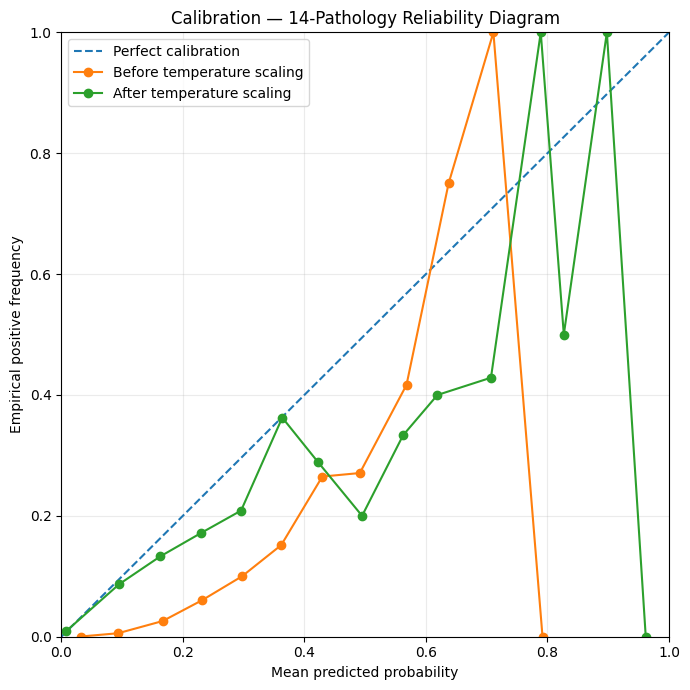

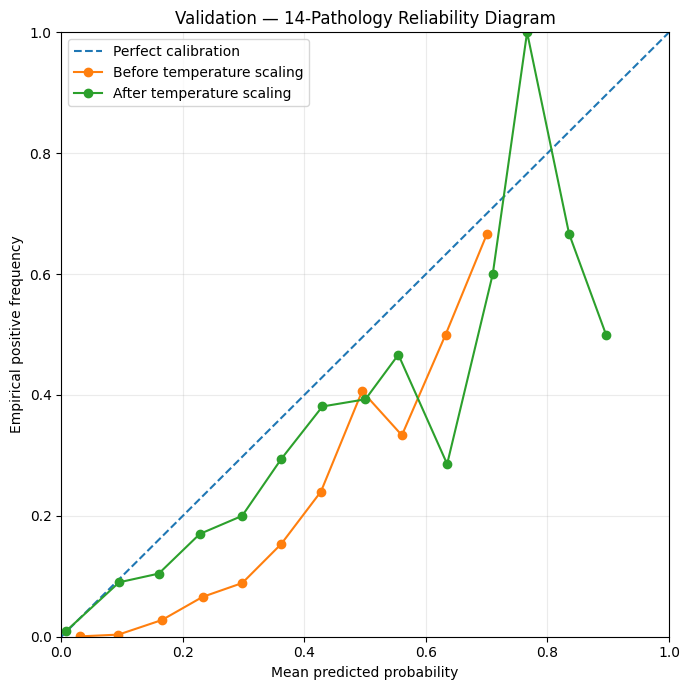

In [19]:
# ============================================================
# 20. Reliability plots — no X-rays
# ============================================================
def plot_reliability(split_name, targets, before_prob, after_prob):
    _, before_bins = binary_ece(
        targets,
        before_prob,
        n_bins=ECE_BINS,
    )

    _, after_bins = binary_ece(
        targets,
        after_prob,
        n_bins=ECE_BINS,
    )

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )

    before_valid = before_bins["count"] > 0
    after_valid = after_bins["count"] > 0

    ax.plot(
        before_bins.loc[before_valid, "mean_probability"],
        before_bins.loc[before_valid, "empirical_frequency"],
        marker="o",
        label="Before temperature scaling",
    )

    ax.plot(
        after_bins.loc[after_valid, "mean_probability"],
        after_bins.loc[after_valid, "empirical_frequency"],
        marker="o",
        label="After temperature scaling",
    )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Empirical positive frequency")
    ax.set_title(
        f"{split_name.title()} — 14-Pathology Reliability Diagram"
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        FIG_DIR / f"{split_name}_pathology14_reliability.png",
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()


plot_reliability(
    "calibration",
    cal_raw["targets"][:, PATHOLOGY_INDICES],
    cal_uncal_prob[:, PATHOLOGY_INDICES],
    cal_calibrated_prob[:, PATHOLOGY_INDICES],
)

plot_reliability(
    "validation",
    val_raw["targets"][:, PATHOLOGY_INDICES],
    val_uncal_prob[:, PATHOLOGY_INDICES],
    val_calibrated_prob[:, PATHOLOGY_INDICES],
)


In [20]:
# ============================================================
# 21. Save fitted calibrator + config + README
# ============================================================
calibrator = {
    "experiment_id":
        EXPERIMENT_ID,
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "method":
        "single_global_temperature_scaling",
    "temperature":
        TEMPERATURE,
    "fit_split":
        "calibration",
    "n_calibration_images":
        len(calibration_df),
    "loss":
        "BCEWithLogitsLoss_over_all_15_outputs",
    "split_manifest_sha256":
        manifest_hash,
    "seed":
        SEED,
    "official_test_used":
        False,
}

with open(
    OUTPUT_DIR / "temperature_scaler.json",
    "w",
) as f:
    json.dump(
        calibrator,
        f,
        indent=2,
    )

config = {
    "experiment_id":
        EXPERIMENT_ID,
    "stage":
        "PostHoc_Global_Temperature_Scaling",
    "base_experiment_id":
        BASELINE_EXPERIMENT_ID,
    "base_model_frozen":
        True,
    "temperature_fit_split":
        "calibration",
    "calibration_count":
        len(calibration_df),
    "validation_count":
        len(val_df),
    "temperature":
        TEMPERATURE,
    "ece_bins":
        ECE_BINS,
    "fit_loss":
        "BCEWithLogitsLoss_all15",
    "per_class_temperature":
        False,
    "calibration_used":
        True,
    "official_test_used":
        False,
    "split_manifest_sha256":
        manifest_hash,
    "seed":
        SEED,
}

with open(
    OUTPUT_DIR / "config.json",
    "w",
) as f:
    json.dump(
        config,
        f,
        indent=2,
    )

environment = {
    "python": sys.version,
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "pydicom": pydicom.__version__,
    "gpu_name": torch.cuda.get_device_name(0),
}

with open(
    OUTPUT_DIR / "environment_info.json",
    "w",
) as f:
    json.dump(
        environment,
        f,
        indent=2,
    )

readme_lines = [
    "Pediatric Chest X-ray — M13 Global Temperature Scaling",
    "=" * 72,
    "",
    "BASE MODEL",
    f"- Experiment: {BASELINE_EXPERIMENT_ID}",
    f"- Validation 14-pathology Macro-AUPRC: {val_rank_uncal['pathology14_macro_AUPRC']:.6f}",
    "",
    "CALIBRATOR",
    "- Method: single global temperature scaling",
    f"- Fitted temperature T: {TEMPERATURE:.8f}",
    "- Fit split: calibration",
    f"- Calibration images: {len(calibration_df)}",
    "- Optimization loss: BCEWithLogitsLoss over all 15 outputs",
    "",
    "CALIBRATION SPLIT — PATHOLOGY 14",
    f"- NLL: {cal_cal_before['pathology14_NLL']:.6f} -> {cal_cal_after['pathology14_NLL']:.6f}",
    f"- Brier: {cal_cal_before['pathology14_Brier']:.6f} -> {cal_cal_after['pathology14_Brier']:.6f}",
    f"- ECE: {cal_cal_before['pathology14_ECE']:.6f} -> {cal_cal_after['pathology14_ECE']:.6f}",
    "",
    "VALIDATION SPLIT — PATHOLOGY 14",
    f"- NLL: {val_cal_before['pathology14_NLL']:.6f} -> {val_cal_after['pathology14_NLL']:.6f}",
    f"- Brier: {val_cal_before['pathology14_Brier']:.6f} -> {val_cal_after['pathology14_Brier']:.6f}",
    f"- ECE: {val_cal_before['pathology14_ECE']:.6f} -> {val_cal_after['pathology14_ECE']:.6f}",
    "",
    "RANKING INTEGRITY",
    f"- Validation Macro-AUPRC change: {val_ap_delta:.12f}",
    f"- Validation Macro-AUROC change: {val_auc_delta:.12f}",
    "",
    "SAFETY",
    "- Official test used: NO",
    "- Base model updated: NO",
    "- Calibration split used for post-hoc fitting: YES",
]

README_RESULTS = "\n".join(readme_lines)

print(README_RESULTS)

with open(
    OUTPUT_DIR / "README_RESULTS.txt",
    "w",
) as f:
    f.write(README_RESULTS)


Pediatric Chest X-ray — M13 Global Temperature Scaling

BASE MODEL
- Experiment: M01_DiseaseFinding_Multitask_Seed42
- Validation 14-pathology Macro-AUPRC: 0.208439

CALIBRATOR
- Method: single global temperature scaling
- Fitted temperature T: 0.41443756
- Fit split: calibration
- Calibration images: 1161
- Optimization loss: BCEWithLogitsLoss over all 15 outputs

CALIBRATION SPLIT — PATHOLOGY 14
- NLL: 0.146027 -> 0.085248
- Brier: 0.033341 -> 0.022557
- ECE: 0.083834 -> 0.005303

VALIDATION SPLIT — PATHOLOGY 14
- NLL: 0.147078 -> 0.086217
- Brier: 0.033614 -> 0.022596
- ECE: 0.084329 -> 0.006239

RANKING INTEGRITY
- Validation Macro-AUPRC change: 0.000000000000
- Validation Macro-AUROC change: 0.000000000000

SAFETY
- Official test used: NO
- Base model updated: NO
- Calibration split used for post-hoc fitting: YES


In [21]:
# ============================================================
# 22. Final integrity gate
# ============================================================
checks = pd.DataFrame([
    {
        "check": "Frozen split SHA-256 verified",
        "passed":
            manifest_hash == EXPECTED_SPLIT_MANIFEST_SHA256,
    },
    {
        "check": "Validation count = 1,159",
        "passed": len(val_df) == 1159,
    },
    {
        "check": "Calibration count = 1,161",
        "passed": len(calibration_df) == 1161,
    },
    {
        "check": "09A checkpoint verified",
        "passed":
            m01_checkpoint.get("experiment_id")
            == BASELINE_EXPERIMENT_ID,
    },
    {
        "check": "09A validation Macro-AUPRC reproduced",
        "passed":
            abs(
                val_rank_uncal["pathology14_macro_AUPRC"]
                - EXPECTED_M01_PATHOLOGY14_AUPRC
            )
            <= M01_REPRO_TOLERANCE,
    },
    {
        "check": "09A model has 0 trainable parameters",
        "passed": trainable_base == 0,
    },
    {
        "check": "Fitted temperature finite",
        "passed": np.isfinite(TEMPERATURE),
    },
    {
        "check": "Fitted temperature > 0",
        "passed": TEMPERATURE > 0,
    },
    {
        "check": "Calibration BCE/NLL did not increase",
        "passed": final_nll <= initial_nll + 1e-8,
    },
    {
        "check": "Validation Macro-AUPRC unchanged",
        "passed": val_ap_delta <= 1e-8,
    },
    {
        "check": "Validation Macro-AUROC unchanged",
        "passed": val_auc_delta <= 1e-8,
    },
    {
        "check": "Calibration split used for fitting",
        "passed": True,
    },
    {
        "check": "Official test not used",
        "passed": True,
    },
    {
        "check": "No preprocessing failures",
        "passed": len(cache_failures) == 0,
    },
])

checks["status"] = checks["passed"].map({
    True: "PASS",
    False: "REVIEW",
})

display(checks)

checks.to_csv(
    OUTPUT_DIR / "final_integrity_status.csv",
    index=False,
)

FINAL_STATUS = (
    "PASS"
    if checks["passed"].all()
    else "REVIEW"
)

print(
    "\nM13 GLOBAL TEMPERATURE SCALING FINAL STATUS:",
    FINAL_STATUS,
)

if FINAL_STATUS == "PASS":
    print(
        "✅ M13 CALIBRATION EXPERIMENT COMPLETED SUCCESSFULLY"
    )
else:
    print(
        "⚠️ REVIEW BEFORE MOVING TO UNCERTAINTY / SELECTIVE PREDICTION"
    )


,check,passed,status
0,Frozen split SHA-256 verified,True,PASS
1,"Validation count = 1,159",True,PASS
2,"Calibration count = 1,161",True,PASS
3,09A checkpoint verified,True,PASS
4,09A validation Macro-AUPRC reproduced,True,PASS
5,09A model has 0 trainable parameters,True,PASS
6,Fitted temperature finite,True,PASS
7,Fitted temperature > 0,True,PASS
8,Calibration BCE/NLL did not increase,True,PASS
9,Validation Macro-AUPRC unchanged,True,PASS



M13 GLOBAL TEMPERATURE SCALING FINAL STATUS: PASS
✅ M13 CALIBRATION EXPERIMENT COMPLETED SUCCESSFULLY


# 23. Export rule

The ZIP includes:

- fitted global temperature;
- calibration/validation logits and probabilities;
- aggregate calibration metrics;
- per-class calibration metrics;
- ECE bin tables;
- reliability diagrams;
- config and integrity checks.

The ZIP does **not** include:

- DICOM files;
- cached `.npy` images;
- raw X-rays;
- official test outputs.

The fitted `temperature_scaler.json` will be the frozen input for the next uncertainty/selective-prediction stage.


In [22]:
# ============================================================
# 24. Package complete M13 output
# ============================================================
ZIP_FILE = Path(
    "/kaggle/working/"
    "M13_GlobalTemperatureScaling_Seed42_All_Outputs.zip"
)

if ZIP_FILE.exists():
    ZIP_FILE.unlink()

source_files = sorted(
    p
    for p in OUTPUT_DIR.rglob("*")
    if p.is_file()
)

if not source_files:
    raise RuntimeError(
        "No M13 experiment outputs were found."
    )

blocked_extensions = {
    ".dcm",
    ".dicom",
    ".npy",
    ".npz",
}

for p in source_files:
    if p.suffix.lower() in blocked_extensions:
        raise RuntimeError(
            "STOP: restricted/raw file detected in output folder: "
            + str(p)
        )

with zipfile.ZipFile(
    ZIP_FILE,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6,
) as zf:
    for p in source_files:
        arcname = (
            Path(EXPERIMENT_ID)
            / p.relative_to(OUTPUT_DIR)
        )

        zf.write(
            p,
            arcname=str(arcname),
        )

with zipfile.ZipFile(ZIP_FILE, "r") as zf:
    corrupt_entry = zf.testzip()
    archive_names = zf.namelist()

if corrupt_entry is not None:
    raise RuntimeError(
        "ZIP integrity failure: "
        + str(corrupt_entry)
    )

required_outputs = [
    "temperature_scaler.json",
    "config.json",
    "aggregate_calibration_metrics.csv",
    "calibration_split_per_class_calibration.csv",
    "validation_split_per_class_calibration.csv",
    "calibration_pathology14_ece_bins.csv",
    "validation_pathology14_ece_bins.csv",
    "calibration_logits_and_probabilities.csv",
    "validation_logits_and_probabilities.csv",
    "final_integrity_status.csv",
    "README_RESULTS.txt",
]

missing_outputs = [
    name
    for name in required_outputs
    if not any(
        x.endswith("/" + name)
        for x in archive_names
    )
]

if missing_outputs:
    raise RuntimeError(
        "ZIP is missing required outputs: "
        + str(missing_outputs)
    )

print("✅ M13 COMPLETE OUTPUT ZIP CREATED")
print("File:", ZIP_FILE)
print(
    "ZIP size:",
    f"{ZIP_FILE.stat().st_size/(1024**2):.2f} MB",
)
print("ZIP integrity: PASS")
print("Official test outputs included: NO")
print("Raw DICOM/cache files included: NO")


✅ M13 COMPLETE OUTPUT ZIP CREATED
File: /kaggle/working/M13_GlobalTemperatureScaling_Seed42_All_Outputs.zip
ZIP size: 0.88 MB
ZIP integrity: PASS
Official test outputs included: NO
Raw DICOM/cache files included: NO


## What to send back

After the run finishes, send:

`M13_GlobalTemperatureScaling_Seed42_All_Outputs.zip`

I will check:

- fitted temperature;
- calibration NLL / Brier / ECE before and after;
- whether calibration improvement generalizes to the validation split;
- per-class behavior, with special caution for tiny rare-class positive counts;
- ranking invariance;
- integrity checks.

If the calibrator is stable, the next notebook will use the frozen calibrated probabilities for:

- uncertainty scores;
- coverage levels such as 100%, 95%, 90%, and 80%;
- risk–coverage analysis;
- AURC;
- Macro-AUPRC / Macro-F1 under selective coverage;
- **tail-positive rejection rate** and head/middle/tail rejection analysis.
